# Lab 4 Tutorial: 

MST-Based Dependency Parsing, Chu-Liu/Edmonds, and Inference-Based Learning


## Learning goals

By the end of this tutorial you should be able to:

1. Recognize a valid rooted dependency tree.
2. Formulate dependency parsing as a maximum-scoring directed spanning-tree problem.
3. Understand why selecting the best incoming edge independently can create a cycle.
4. Understand the main steps of the Chu-Liu/Edmonds algorithm.
5. Understand cycle contraction and adjusted edge weights.
6. Understand inference-based structured perceptron learning.
7. Distinguish **inference** (finding the best tree for fixed weights) from **training** (changing the weights).

> **Important:** The assignment asks you to implement Chu-Liu/Edmonds yourself. Do not use `networkx.maximum_spanning_arborescence()` in your submission.

In [7]:
from itertools import product
from collections import Counter
import pandas as pd

## 1. Dependency trees

For a sentence with `ROOT`, every ordinary word must have exactly one incoming dependency arc.

A valid rooted dependency tree must satisfy:

- `ROOT` has no incoming edge.
- Every non-root word has exactly one head.
- No self-loop is allowed.
- There is no directed cycle.
- Every word is reachable from `ROOT`.
- For `n` non-root words, the tree has exactly `n` arcs.

Example:

```text
ROOT -> saw
saw  -> John
saw  -> Mary
```

This is a valid tree for:

```text
ROOT John saw Mary
```

In [8]:
def is_valid_tree_demo(tokens, arcs, root="ROOT"):
    non_root = [w for w in tokens if w != root]

    if len(arcs) != len(non_root):
        return False

    heads = {}
    for head, dep in arcs:
        if head == dep or dep == root:
            return False
        if dep in heads:
            return False
        heads[dep] = head

    if set(heads) != set(non_root):
        return False

    for start in non_root:
        cur = start
        seen = set()
        while cur != root:
            if cur in seen or cur not in heads:
                return False
            seen.add(cur)
            cur = heads[cur]

    return True

tokens = ["ROOT", "John", "saw", "Mary"]
gold = [
    ("ROOT", "saw"),
    ("saw", "John"),
    ("saw", "Mary")
]
print("Valid tree:", is_valid_tree_demo(tokens, gold))

Valid tree: True


## 2. MST formulation of dependency parsing

Suppose every possible dependency arc has a score.

The score of a complete dependency tree is:

$$
Score(G)=\sum_{(h,d)\in G} Score(h\rightarrow d)
$$

The parser wants:

$$
\boxed{
G^*=\arg\max_{G\in T(x)} Score(G)
}
$$

where `T(x)` is the set of valid dependency trees for the sentence.

For a very small graph we can enumerate all possible trees. This is useful as a **reference parser** for checking implementation.

In [9]:
tokens = ["ROOT", "Researchers", "analyze", "data", "carefully"]

score = {
    ("ROOT","Researchers"):1,
    ("ROOT","analyze"):7,
    ("ROOT","data"):1,
    ("ROOT","carefully"):1,
    ("Researchers","analyze"):2,
    ("Researchers","data"):2,
    ("Researchers","carefully"):2,
    ("analyze","Researchers"):6,
    ("analyze","data"):7,
    ("analyze","carefully"):6,
    ("data","Researchers"):2,
    ("data","analyze"):3,
    ("data","carefully"):3,
    ("carefully","Researchers"):2,
    ("carefully","analyze"):3,
    ("carefully","data"):4,
}

def exhaustive_reference(tokens, score, root="ROOT"):
    non_root = [w for w in tokens if w != root]
    choices = [[h for h in tokens if h != dep] for dep in non_root]
    best_score = float("-inf")
    best_tree = None

    for heads in product(*choices):
        tree = list(zip(heads, non_root))
        if is_valid_tree_demo(tokens, tree, root):
            total = sum(score[a] for a in tree)
            if total > best_score:
                best_score = total
                best_tree = tree

    return best_score, best_tree

best_score, best_tree = exhaustive_reference(tokens, score)
print("Reference MST score:", best_score)
print("Reference MST:", best_tree)

Reference MST score: 26
Reference MST: [('analyze', 'Researchers'), ('ROOT', 'analyze'), ('analyze', 'data'), ('analyze', 'carefully')]


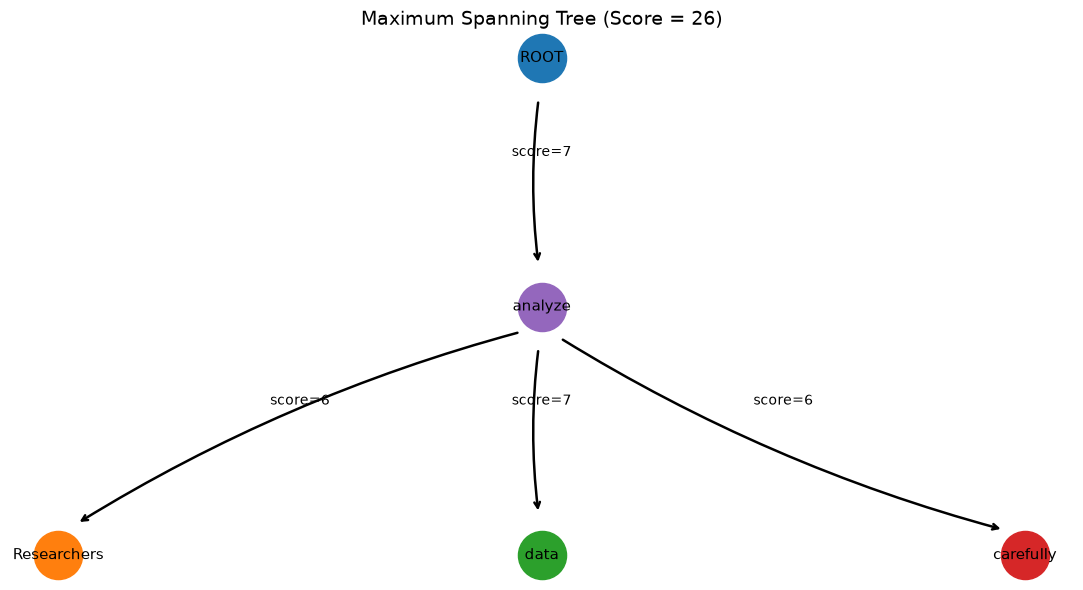

In [10]:
import matplotlib.pyplot as plt
from collections import defaultdict, deque

def visualize_dependency_tree(tokens, arcs, score=None, title="Maximum Spanning Tree"):
    children = defaultdict(list)

    for head, dep in arcs:
        children[head].append(dep)

    # Compute each node's depth from ROOT.
    depth = {tokens[0]: 0}
    queue = deque([tokens[0]])

    while queue:
        node = queue.popleft()
        for child in children[node]:
            depth[child] = depth[node] + 1
            queue.append(child)

    # Arrange nodes level-by-level.
    levels = defaultdict(list)
    for node in tokens:
        levels[depth.get(node, 0)].append(node)

    positions = {}
    max_width = max(len(nodes_at_level) for nodes_at_level in levels.values())

    for level, nodes_at_level in levels.items():
        n = len(nodes_at_level)
        for i, node in enumerate(nodes_at_level):
            x = (i + 1) / (n + 1) * max_width
            y = -level
            positions[node] = (x, y)

    fig, ax = plt.subplots(figsize=(11, 6))

    # Draw nodes.
    for node, (x, y) in positions.items():
        ax.scatter(x, y, s=1200)
        ax.text(x, y, node, ha="center", va="center", fontsize=11)

    # Draw directed dependency arcs.
    for head, dep in arcs:
        x1, y1 = positions[head]
        x2, y2 = positions[dep]

        ax.annotate(
            "",
            xy=(x2, y2 + 0.08),
            xytext=(x1, y1 - 0.08),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.8,
                shrinkA=18,
                shrinkB=18,
                connectionstyle="arc3,rad=0.08"
            )
        )

        if score is not None and (head, dep) in score:
            ax.text(
                (x1 + x2) / 2,
                (y1 + y2) / 2 + 0.12,
                f"score={score[(head, dep)]}",
                ha="center",
                va="center",
                fontsize=10
            )

    ax.set_title(title, fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize the MST found in the previous cell.
visualize_dependency_tree(
    tokens,
    best_tree,
    score=score,
    title=f"Maximum Spanning Tree (Score = {best_score})"
)


## 3. Why greedy incoming-edge selection is not enough

Chu-Liu/Edmonds begins by selecting the highest-scoring incoming edge for each non-root node.

For the graph below:

```text
ROOT -> A = 5
ROOT -> B = 4
ROOT -> C = 3

A -> B = 10
B -> A = 10
A -> C = 7
B -> C = 8
```

The greedy choices include:

```text
B -> A
A -> B
B -> C
```

The first two edges form:

$$
A\rightarrow B\rightarrow A
$$

This is a directed cycle.

A dependency tree cannot contain this cycle.

In [11]:
cycle_tokens = ["ROOT", "A", "B", "C"]
cycle_score = {
    ("ROOT","A"):5,
    ("ROOT","B"):4,
    ("ROOT","C"):3,
    ("A","B"):10,
    ("B","A"):10,
    ("A","C"):7,
    ("B","C"):8,
    ("C","A"):2,
    ("C","B"):2,
}

greedy = {}
for dep in cycle_tokens:
    if dep == "ROOT":
        continue
    candidates = [
        (head, dep, cycle_score[(head, dep)])
        for head in cycle_tokens
        if head != dep
    ]
    greedy[dep] = max(candidates, key=lambda x: x[2])

print("Greedy incoming edges:")
for edge in greedy.values():
    print(edge)

Greedy incoming edges:
('B', 'A', 10)
('A', 'B', 10)
('B', 'C', 8)


## 4. Cycle detection

Represent the selected incoming edges as a parent map:

```text
parent[A] = B
parent[B] = A
parent[C] = B
```

Starting from a node and repeatedly following its parent lets you detect a repeated node.

For example:

```text
A -> B -> A
```

means a cycle has been found.

### Pseudocode

```text
for each node:
    start from the node
    follow parent pointers
    if a node is visited twice:
        a cycle exists
```

Your Task 3 asks you to implement this idea.

## 5. Cycle contraction

Suppose the selected cycle is:

$$
A\rightarrow B
$$

and

$$
B\rightarrow A
$$

with scores:

$$
Score(A\rightarrow B)=10
$$

$$
Score(B\rightarrow A)=10
$$

Then:

$$
W_C=10+10=20
$$

We temporarily replace `{A, B}` with one supernode.

For an external edge entering the cycle:

$$
u\rightarrow v,\quad v\in C
$$

use:

$$
\boxed{
w'(u\rightarrow C)
=
w(u\rightarrow v)
+
W_C
-
w(parent(v)\rightarrow v)
}
$$

For `ROOT -> A`:

$$
5+20-10=15
$$

For `ROOT -> B`:

$$
4+20-10=14
$$

So:

| External edge | Original | Cycle total | Removed cycle edge | Adjusted |
|---|---:|---:|---|---:|
| ROOT -> A | 5 | 20 | B -> A (10) | 15 |
| ROOT -> B | 4 | 20 | A -> B (10) | 14 |

This adjustment is essential because the external incoming edge replaces one of the cycle's selected incoming edges.

## 6. Chu-Liu/Edmonds: complete algorithm idea

The algorithm is recursive.

### Step 1
For every non-root node, choose its highest-scoring incoming edge.

### Step 2
Check the selected edges.

- If there is **no cycle**, return the selected tree.
- If there is a cycle, continue.

### Step 3
Contract the cycle into a supernode.

### Step 4
Recalculate the weights of edges entering and leaving the cycle.

### Step 5
Run Chu-Liu/Edmonds again on the contracted graph.

### Step 6
Expand the contracted solution.

If the final solution enters the cycle through node `v`, remove the originally selected incoming cycle edge of `v` and keep the remaining cycle edges.

### Pseudocode

```text
CLE(nodes, edges, root):

    choose maximum incoming edge for each non-root node

    if no cycle:
        return selected edges

    find cycle C

    contract C into supernode

    recursively solve contracted graph

    expand C

    return final tree
```

Your Task 5 asks you to implement this algorithm from scratch.

## 7. Implementation advice for Task 5

A clean implementation can use:

```python
select_best_incoming(...)
detect_cycle(...)
contract_cycle(...)
expand_cycle(...)
chu_liu_edmonds(...)
```

When contracting a cycle, store metadata for every contracted edge.

For an edge entering the cycle:

```text
u -> v, where v is inside the cycle
```

remember `v`. If that edge is selected in the recursive solution, the original cycle edge entering `v` must be removed during expansion.

For an edge leaving the cycle:

```text
v -> u, where v is inside the cycle
```

remember the original edge so it can be restored after recursion.



## 8. Inference-based structured learning

For fixed weights, inference finds the highest-scoring tree:

$$
\boxed{
G_{pred}
=
\arg\max_{G\in T(x)}
\mathbf{w}\cdot\Phi(x,G)
}
$$

Training changes the weights when the prediction is wrong:

$$
\boxed{
\mathbf{w}_{new}
=
\mathbf{w}_{old}
+
\Phi(x,G_{gold})
-
\Phi(x,G_{pred})
}
$$

Feature by feature:

$$
\boxed{
w_{new}[f]
=
w_{old}[f]
+
\Phi(x,G_{gold})[f]
-
\Phi(x,G_{pred})[f]
}
$$

So:

- gold-only features increase;
- predicted-only features decrease;
- equal counts produce no net change.

The important point is that **the MST inference algorithm is called inside training**.

In [12]:
def arc_features_demo(tokens, pos, head, dep):
    hi = tokens.index(head)
    di = tokens.index(dep)
    direction = "RIGHT" if hi < di else "LEFT"
    distance = abs(hi - di)

    return [
        f"HEAD_WORD={head}",
        f"DEP_WORD={dep}",
        f"HEAD_POS={pos[head]}",
        f"DEP_POS={pos[dep]}",
        f"DIRECTION={direction}",
        f"DISTANCE={distance}",
        f"PAIR={head}->{dep}",
    ]

tokens = ["ROOT", "John", "saw", "Mary"]
pos = {"ROOT":"ROOT", "John":"NOUN", "saw":"VERB", "Mary":"NOUN"}

print(arc_features_demo(tokens, pos, "saw", "Mary"))

['HEAD_WORD=saw', 'DEP_WORD=Mary', 'HEAD_POS=VERB', 'DEP_POS=NOUN', 'DIRECTION=RIGHT', 'DISTANCE=1', 'PAIR=saw->Mary']


## 9. Concrete perceptron example

Suppose:

```text
Gold:
ROOT -> saw
saw  -> John
saw  -> Mary

Predicted:
ROOT -> saw
saw  -> John
John -> Mary
```

Only Mary's head is wrong.

The update is:

$$
\mathbf{w}_{new}
=
\mathbf{w}_{old}
+
\Phi(x,G_{gold})
-
\Phi(x,G_{pred})
$$

Features of `saw -> Mary` receive positive contributions. Features occurring only in `John -> Mary` receive negative contributions.

Thus the gold structure becomes relatively more attractive during the next inference step.

## 10. Full training loop

```text
initialize weights

for epoch:
    mistakes = 0

    for each training sentence:
        build arc scores using current weights

        predicted_tree =
            Chu-Liu/Edmonds(current arc scores)

        if predicted_tree != gold_tree:
            gold_features = Phi(gold_tree)
            predicted_features = Phi(predicted_tree)

            weights =
                weights
                + gold_features
                - predicted_features

            mistakes += 1

    record mistakes
```

### Key distinction

**Inference**

```text
weights -> best tree
```

**Training**

```text
weights -> inference -> predicted tree
        -> compare with gold
        -> update weights
```